# Importing all required libraries

In [ ]:
# !pip uninstall flwr -y
# !pip install flwr==1.7.0

In [ ]:
# 1. Uninstall the conflicting versions
!pip uninstall -y protobuf google-cloud-aiplatform

# 2. Install the specific compatible versions
!pip install "protobuf==4.25.3"
!pip install -U flwr["simulation"]

# 3. Force-restart the backend (you'll see a 'Crash' message, ignore it, it's just the restart)
import os
os.kill(os.getpid(), 9)

In [ ]:
import os
import glob
import shutil
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, precision_score, recall_score, f1_score
)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, BatchNormalization, Dropout, Concatenate,
    GlobalAveragePooling2D, Conv2D, MaxPooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.utils import Sequence
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.losses import BinaryFocalCrossentropy

import flwr as fl

warnings.filterwarnings("ignore")

print("All libraries imported successfully")
print("Flower version:", fl.__version__)
print("TensorFlow version:", tf.__version__)

All libraries imported successfully
Flower version: 1.27.0
TensorFlow version: 2.19.0


# Kaggle setup

In [ ]:
if not os.path.exists('/root/.kaggle'):
    os.makedirs('/root/.kaggle')

!mv kaggle.json /root/.kaggle/ 2>/dev/null || true
!chmod 600 /root/.kaggle/kaggle.json 2>/dev/null || true

# Model A

### Extracting dataset from kaggle

In [ ]:
!kaggle datasets download -d mehradaria/leukemia -p /content/

with zipfile.ZipFile('/content/leukemia.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/A_Raw/')

Dataset URL: https://www.kaggle.com/datasets/mehradaria/leukemia
License(s): ODbL-1.0
100% 110M/110M [00:00<00:00, 176MB/s]



### Structuring folder

In [ ]:
base_path = '/content/Institution_Alpha'
os.makedirs(f'{base_path}/Healthy',   exist_ok=True)
os.makedirs(f'{base_path}/Leukemia',  exist_ok=True)

In [ ]:
for p in glob.glob('/content/A_Raw/**/Benign/*.*', recursive=True):
    shutil.copy(p, f'{base_path}/Healthy/')

for sub in ['Early', 'Pre', 'Pro']:
    for p in glob.glob(f'/content/A_Raw/**/{sub}/*.*', recursive=True):
        shutil.copy(p, f'{base_path}/Leukemia/')

print(f"Institution Alpha Ready: {len(os.listdir(base_path+'/Healthy'))} Healthy, " f"{len(os.listdir(base_path+'/Leukemia'))} Leukemia images.")


Institution Alpha Ready: 504 Healthy, 2752 Leukemia images.


### Importing Clinical Data

In [ ]:
df_alpha = pd.read_csv('/content/hospital_A_clinical.csv')

In [ ]:
def remap_path_alpha(old_path):
    filename = os.path.basename(old_path)

    for prefix in ['A_Pre_', 'A_Early_', 'A_Pro_', 'A_Benign_', 'A_H_', 'A_L_']:
        filename = filename.replace(prefix, '')

    subfolder = 'Healthy' if ('Healthy' in old_path or '_H_' in filename or 'Benign' in old_path) else 'Leukemia'

    return f'/content/Institution_Alpha/{subfolder}/{filename}'

In [ ]:
df_alpha['image_path'] = df_alpha['image_path'].apply(remap_path_alpha)

In [ ]:
df_alpha['Patient_ID'] = df_alpha['image_path'].apply(lambda x: os.path.basename(x).split('-')[-1].split('.')[0])

valid_paths = df_alpha['image_path'].apply(os.path.exists)
missing_count = (~valid_paths).sum()

if missing_count > 0:
    print(f"Warning: {missing_count} images not found on disk. Dropping missing rows...")
    df_alpha = df_alpha[valid_paths].reset_index(drop=True)
else:
    print("All CSV image paths successfully verified.")

print(f"Total valid images locked in for Alpha: {len(df_alpha)}")

All CSV image paths successfully verified.
Total valid images locked in for Alpha: 3256


In [ ]:
features_alpha = ['WBC_count', 'LDH_level', 'Hemoglobin', 'Platelet_count',
                  'RBC_count', 'Hematocrit', 'Lymphocyte_percentage', 'Neutrophil_percentage', 'Uric_acid']

In [ ]:
unique_patients_alpha = df_alpha['Patient_ID'].unique()

### Spliting data into train and test

In [ ]:
train_ids_alpha, temp_ids_alpha = train_test_split(
    unique_patients_alpha, test_size=0.3, random_state=42
)

val_ids_alpha, test_ids_alpha = train_test_split(
    temp_ids_alpha, test_size=0.5, random_state=42
)

train_df_alpha = df_alpha[df_alpha['Patient_ID'].isin(train_ids_alpha)].reset_index(drop=True)
val_df_alpha   = df_alpha[df_alpha['Patient_ID'].isin(val_ids_alpha)].reset_index(drop=True)
test_df_alpha  = df_alpha[df_alpha['Patient_ID'].isin(test_ids_alpha)].reset_index(drop=True)

print(f"Alpha Split done: {len(train_df_alpha)} Train, {len(val_df_alpha)} Val, {len(test_df_alpha)} Test rows.")

Alpha Split done: 2268 Train, 494 Val, 494 Test rows.


### Scaling data

In [ ]:
scaler_alpha = StandardScaler()

train_df_alpha[features_alpha] = scaler_alpha.fit_transform(train_df_alpha[features_alpha])

val_df_alpha[features_alpha]   = scaler_alpha.transform(val_df_alpha[features_alpha])
test_df_alpha[features_alpha]  = scaler_alpha.transform(test_df_alpha[features_alpha])

print(f"Alpha Scaling done: {len(train_df_alpha)} Train, {len(val_df_alpha)} Val, {len(test_df_alpha)} Test rows.")

Alpha Scaling done: 2268 Train, 494 Val, 494 Test rows.


### Class Weights

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_alpha = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_df_alpha['Diagnosis'].values
)

class_weight_dict_alpha = {0: class_weights_alpha[0], 1: class_weights_alpha[1]}
print(f"Alpha Class Weights → Healthy: {class_weights_alpha[0]:.2f}, Leukemia: {class_weights_alpha[1]:.2f}")

Alpha Class Weights → Healthy: 3.25, Leukemia: 0.59


In [ ]:
df_majority = train_df_alpha[train_df_alpha['Diagnosis'] == 1]
df_minority = train_df_alpha[train_df_alpha['Diagnosis'] == 0]

df_minority_upsampled = df_minority.sample(n=len(df_majority), replace=True, random_state=42)

train_df_balanced = pd.concat([df_majority, df_minority_upsampled]).sample(frac=1).reset_index(drop=True)

print(f"Balanced Training Set: {len(train_df_balanced[train_df_balanced['Diagnosis'] == 0])} Healthy, {len(train_df_balanced[train_df_balanced['Diagnosis'] == 1])} Leukemia")

Balanced Training Set: 1919 Healthy, 1919 Leukemia


### Data Agumentation

In [ ]:
aug_alpha = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)

### THE MULTIMODAL DATA ENGINE

In [ ]:
class LeukemiaDataGeneratorAlpha(tf.keras.utils.Sequence):

    def __init__(self, dataframe, batch_size=32, target_size=(224, 224), shuffle=True, is_training=True):
        self.df = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
        self.target_size = target_size
        self.shuffle = shuffle
        self.is_training = is_training
        self.features = ['WBC_count', 'LDH_level', 'Hemoglobin', 'Platelet_count',
                         'RBC_count', 'Hematocrit', 'Lymphocyte_percentage', 'Neutrophil_percentage', 'Uric_acid']

        self.on_epoch_end()

    def __len__(self): return int(np.floor(len(self.df) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle: self.df = self.df.sample(frac=1).reset_index(drop=True)

    def __getitem__(self, index):
        batch = self.df.iloc[index * self.batch_size : (index + 1) * self.batch_size]
        images = []

        for p in batch['image_path']:
            img = img_to_array(load_img(p, target_size=self.target_size)) / 255.0
            if self.is_training: img = aug_alpha.random_transform(img)
            images.append(img)

        X_img = np.array(images)
        X_tab = batch[self.features].values.astype(np.float32)

        y = batch['Diagnosis'].values.astype(np.float32)

        return (X_img, X_tab), y

In [ ]:
alpha_train_gen = LeukemiaDataGeneratorAlpha(train_df_balanced, batch_size=32, is_training=True)
alpha_val_gen   = LeukemiaDataGeneratorAlpha(val_df_alpha,   batch_size=32, is_training=False, shuffle=False)
alpha_test_gen  = LeukemiaDataGeneratorAlpha(test_df_alpha,  batch_size=32, is_training=False, shuffle=False)

### THE DUAL-INPUT ARCHITECTURE

In [ ]:
def build_model_alpha():

    # --- IMAGE BRANCH ---
    img_input = Input(shape=(224, 224, 3), name="image_input")

    # Block 1
    x = Conv2D(8, (3, 3), activation='relu', padding='same',kernel_regularizer=l2(1e-4))(img_input)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.3)(x)

    # Block 2
    x = Conv2D(16, (3, 3), activation='relu', padding='same',kernel_regularizer=l2(1e-4))(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.35)(x)

    x = GlobalAveragePooling2D()(x)
    img_features = Dense(32, activation='relu',kernel_regularizer=l2(1e-4))(x)

    # --- CLINICAL BRANCH ---
    tab_input = Input(shape=(9,), name="clinical_input")
    t = Dense(16, activation='relu', kernel_regularizer=l2(1e-4))(tab_input)
    t = Dropout(0.4)(t)
    tab_features = Dense(8, activation='relu', kernel_regularizer=l2(1e-4))(t)

    # --- FUSION ---
    merged = Concatenate()([img_features, tab_features])
    z = Dense(16, activation='relu', kernel_regularizer=l2(1e-4))(merged)
    z = Dropout(0.4)(z)

    output = Dense(1, activation='sigmoid', name="diagnosis")(z)

    model = Model(inputs=[img_input, tab_input], outputs=output)

    model.compile(
        optimizer=Adam(0.0001),
        loss=BinaryFocalCrossentropy(gamma=2.0, alpha=0.25),
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.Precision(name='precision')
        ]
    )

    return model

In [ ]:
local_model_alpha = build_model_alpha()
local_model_alpha.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 224, 224,  │        224 │ image_input[0][0] │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 112, 112,  │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 112, 112,  │          0 │ max_pooling2d_2[… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 112, 112,  │      1,168 │ dropout_4[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 56, 56,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clinical_input      │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 56, 56,    │          0 │ max_pooling2d_3[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 16)        │        160 │ clinical_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 16)        │          0 │ dropout_5[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 16)        │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │        544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 8)         │        136 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 40)        │          0 │ dense_4[0][0],    │
│ (Concatenate)       │                   │            │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 16)        │        656 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 16)        │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diagnosis (Dense)   │ (None, 1)         │         17 │ dropout_7[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,905 (11.35 KB)

 Trainable params: 2,905 (11.35 KB)

 Non-trainable params: 0 (0.00 B)

### THE PRIVACY WRAPPER (FLOWER CLIENT)

In [ ]:
class LeukemiaClientAlpha(fl.client.NumPyClient):
    def __init__(self, model, train_generator, val_generator, class_weights):
        self.model     = model
        self.train_gen = train_generator
        self.val_gen   = val_generator
        self.class_weights = class_weights

    def get_parameters(self, config):
        """Differential Privacy: add tiny Gaussian noise before sharing weights."""
        weights = self.model.get_weights()
        noisy_weights = [w + np.random.normal(0, 0.001, w.shape) for w in weights]

        return noisy_weights

    def fit(self, parameters, config):
        """Receive global weights, train locally, return updated weights."""
        self.model.set_weights(parameters)

        print("\nTraining on local patient silo...")
        local_epochs = config.get("local_epochs", 2)

        self.model.fit(
            self.train_gen,
            epochs=local_epochs,
            class_weight=self.class_weights,
            verbose=1
        )

        return self.get_parameters(config={}), len(self.train_gen.df), {}

    def evaluate(self, parameters, config):
        """Evaluate global model on local validation set."""
        self.model.set_weights(parameters)

        print("\nEvaluating Global Model on local held-out validation set...")
        loss, accuracy = self.model.evaluate(self.val_gen, verbose=0)

        return float(loss), len(self.val_gen.df), {"accuracy": float(accuracy)}

print("Federated Client Logic Initialized.")

Federated Client Logic Initialized.


### Training

In [ ]:
callbacks_alpha = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model_alpha.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

In [ ]:
history_alpha = local_model_alpha.fit(
    alpha_train_gen,
    validation_data=alpha_val_gen,
    epochs=15,
    callbacks=callbacks_alpha,
    class_weight=class_weight_dict_alpha,
    verbose=1
)

Epoch 1/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.5364 - auc: 0.6360 - loss: 0.2910 - precision: 0.5808 - recall: 0.3155
Epoch 1: val_loss improved from None to 0.23852, saving model to best_model_alpha.keras

Epoch 1: finished saving model to best_model_alpha.keras
119/119 ━━━━━━━━━━━━━━━━━━━━ 56s 415ms/step - accuracy: 0.5509 - auc: 0.6572 - loss: 0.2746 - precision: 0.6046 - recall: 0.2918 - val_accuracy: 0.3375 - val_auc: 0.8546 - val_loss: 0.2385 - val_precision: 0.9886 - val_recall: 0.2153
Epoch 2/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.5751 - auc: 0.7007 - loss: 0.2297 - precision: 0.7239 - recall: 0.2387
Epoch 2: val_loss did not improve from 0.23852
119/119 ━━━━━━━━━━━━━━━━━━━━ 48s 402ms/step - accuracy: 0.5672 - auc: 0.7092 - loss: 0.2231 - precision: 0.7341 - recall: 0.2115 - val_accuracy: 0.2396 - val_auc: 0.9079 - val_loss: 0.2646 - val_precision: 1.0000 - val_recall: 0.0965
Epoch 3/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accur

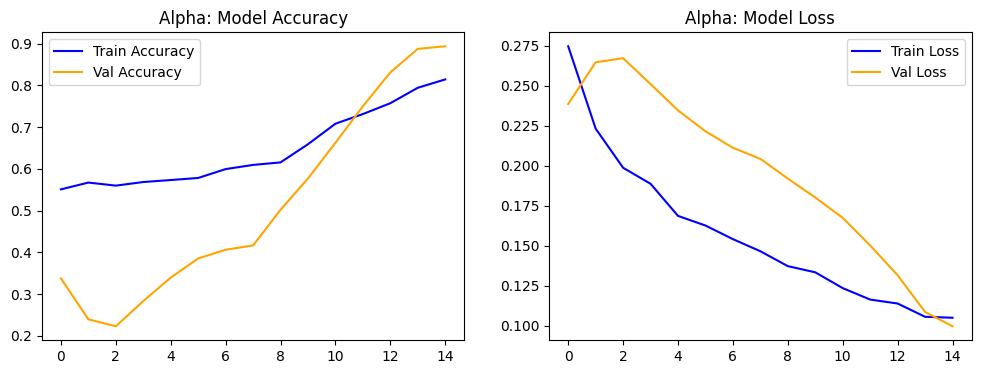

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_alpha.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history_alpha.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Alpha: Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_alpha.history['loss'], label='Train Loss', color='blue')
plt.plot(history_alpha.history['val_loss'], label='Val Loss', color='orange')
plt.title('Alpha: Model Loss')
plt.legend()
plt.show()

In [ ]:
def evaluate_on_test(model, test_gen, test_df, title="Model"):
    all_probs = model.predict(test_gen, verbose=1).flatten()
    threshold = 0.3
    all_preds = (all_probs > threshold).astype(int)

    n = len(all_probs)
    all_true = test_df['Diagnosis'].values[:n].astype(int)

    # Core metrics
    acc  = accuracy_score(all_true, all_preds)
    auc  = roc_auc_score(all_true, all_probs)
    prec = precision_score(all_true, all_preds)
    rec  = recall_score(all_true, all_preds)
    f1   = f1_score(all_true, all_preds)

    # Confusion matrix
    cm = confusion_matrix(all_true, all_preds)

    print(f"\n{'='*50}")
    print(f"  TEST SET RESULTS — {title}")
    print(f"{'='*50}")
    print(f"  Accuracy     : {acc:.4f}")
    print(f"  AUC-ROC      : {auc:.4f}")
    print(f"  Precision    : {prec:.4f}")
    print(f"  Recall       : {rec:.4f}")
    print(f"  F1 Score     : {f1:.4f}")
    print(f"{'='*50}\n")

    print("Confusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(classification_report(all_true, all_preds))

In [ ]:
evaluate_on_test(local_model_alpha, alpha_test_gen, test_df_alpha, title="Institution Alpha")

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step

  TEST SET RESULTS — Institution Alpha
  Accuracy     : 0.9583
  AUC-ROC      : 0.9891
  Precision    : 0.9658
  Recall       : 0.9850
  F1 Score     : 0.9753

Confusion Matrix:
[[ 65  14]
 [  6 395]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.82      0.87        79
           1       0.97      0.99      0.98       401

    accuracy                           0.96       480
   macro avg       0.94      0.90      0.92       480
weighted avg       0.96      0.96      0.96       480

